# Notebook 9: cross-dataset T-cell label compatibility

The bidirectional classifiers transfer B-cell and monocyte labels well but disagree strongly on fine T-cell labels. This notebook determines whether that failure reflects model behavior or incompatible label definitions.

It compares marker programs, both transfer confusion matrices, and a T-cell-only Harmony representation. It then creates a **non-destructive broad-label proposal** for future combined modeling. It does not train a T-cell specialist and never overwrites the original PBMC3k or PBMC4k annotations.

## 1. Imports, paths, and fixed definitions

In [1]:
from pathlib import Path
import warnings

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scanpy.external as sce
import seaborn as sns
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, precision_recall_fscore_support, normalized_mutual_info_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
sc.settings.verbosity = 2
sc.settings.set_figure_params(dpi=100, facecolor="white")
sns.set_theme(style="whitegrid")

cwd = Path.cwd().resolve()
root_candidates = []
for location in [cwd, *cwd.parents]:
    root_candidates.extend([location, location / "26-the-backpropagators-analysis"])
ROOT = next((p for p in root_candidates if (p / "PBMC_integrated").is_dir() and (p / "PBMC3k").is_dir()), None)
if ROOT is None:
    raise FileNotFoundError(f"Could not locate the analysis repository from {cwd}")

INTEGRATED = ROOT / "PBMC_integrated"
INPUT = INTEGRATED / "data" / "processed" / "pbmc3k_pbmc4k_harmony_integrated.h5ad"
DATA_OUT = INTEGRATED / "data" / "processed"
TABLES = INTEGRATED / "results" / "tables"
FIGURES = INTEGRATED / "results" / "figures"
for directory in (DATA_OUT, TABLES, FIGURES):
    directory.mkdir(parents=True, exist_ok=True)

T_CELL_TYPES = [
    "Activated/transitional T cells",
    "Cytotoxic CD8 T cells",
    "IL7R+ memory/helper T cells",
    "Naive/resting T cells",
]
RARE_EXCLUDED = ["Dendritic cells", "Platelets"]
MARKER_PROGRAMS = {
    "pan_T": ["CD3D", "CD3E", "TRAC", "LTB"],
    "naive_resting": ["CCR7", "TCF7", "LEF1", "MAL", "NOSIP", "LTB"],
    "helper_memory": ["IL7R", "LTB", "AQP3", "MALAT1", "GIMAP7"],
    "cytotoxic": ["CCL5", "NKG7", "CST7", "CTSW", "GZMK", "GZMA", "CD8A", "CD8B"],
    "immediate_early_activation": ["JUN", "JUNB", "FOS", "FOSB", "DUSP1", "CD69", "SOCS3"],
}
RANDOM_STATE = 0
print(f"Repository root: {ROOT}")

Repository root: /Users/Ema/Desktop/cosmos/26-the-backpropagators-analysis


## 2. Compare marker programs by dataset and reviewed label

Scores are simple means of normalized log-expression across each marker panel. They are descriptive evidence, not automatically generated ground truth.

pan_T  naive_resting  helper_memory  \
dataset cell_type                                                             
PBMC3k  Activated/transitional T cells  1.837          0.749          2.167   
        Cytotoxic CD8 T cells           1.896          0.517          2.091   
        IL7R+ memory/helper T cells     2.403          1.132          2.581   
        Naive/resting T cells           2.096          1.168          2.298   
PBMC4k  Activated/transitional T cells  2.028          1.236          2.261   
        Cytotoxic CD8 T cells           1.913          0.580          2.115   
        IL7R+ memory/helper T cells     2.265          1.084          2.590   
        Naive/resting T cells           2.085          1.211          2.471   

                                        cytotoxic  immediate_early_activation  
dataset cell_type                                                              
PBMC3k  Activated/transitional T cells      0.890                       1.573  
        Cytotoxic CD8 T cells               2.084                       1.645  
        IL7R+ memory/helper T cells         0.271                       2.092  
        Naive/resting T cells               0.258                       1.797  
PBMC4k  Activated/transitional T cells      0.283                       2.001  
        Cytotoxic CD8 T cells               1.903                       1.730  
        IL7R+ memory/helper T cells         0.338                       1.919  
        Naive/resting T cells               0.279                       0.727

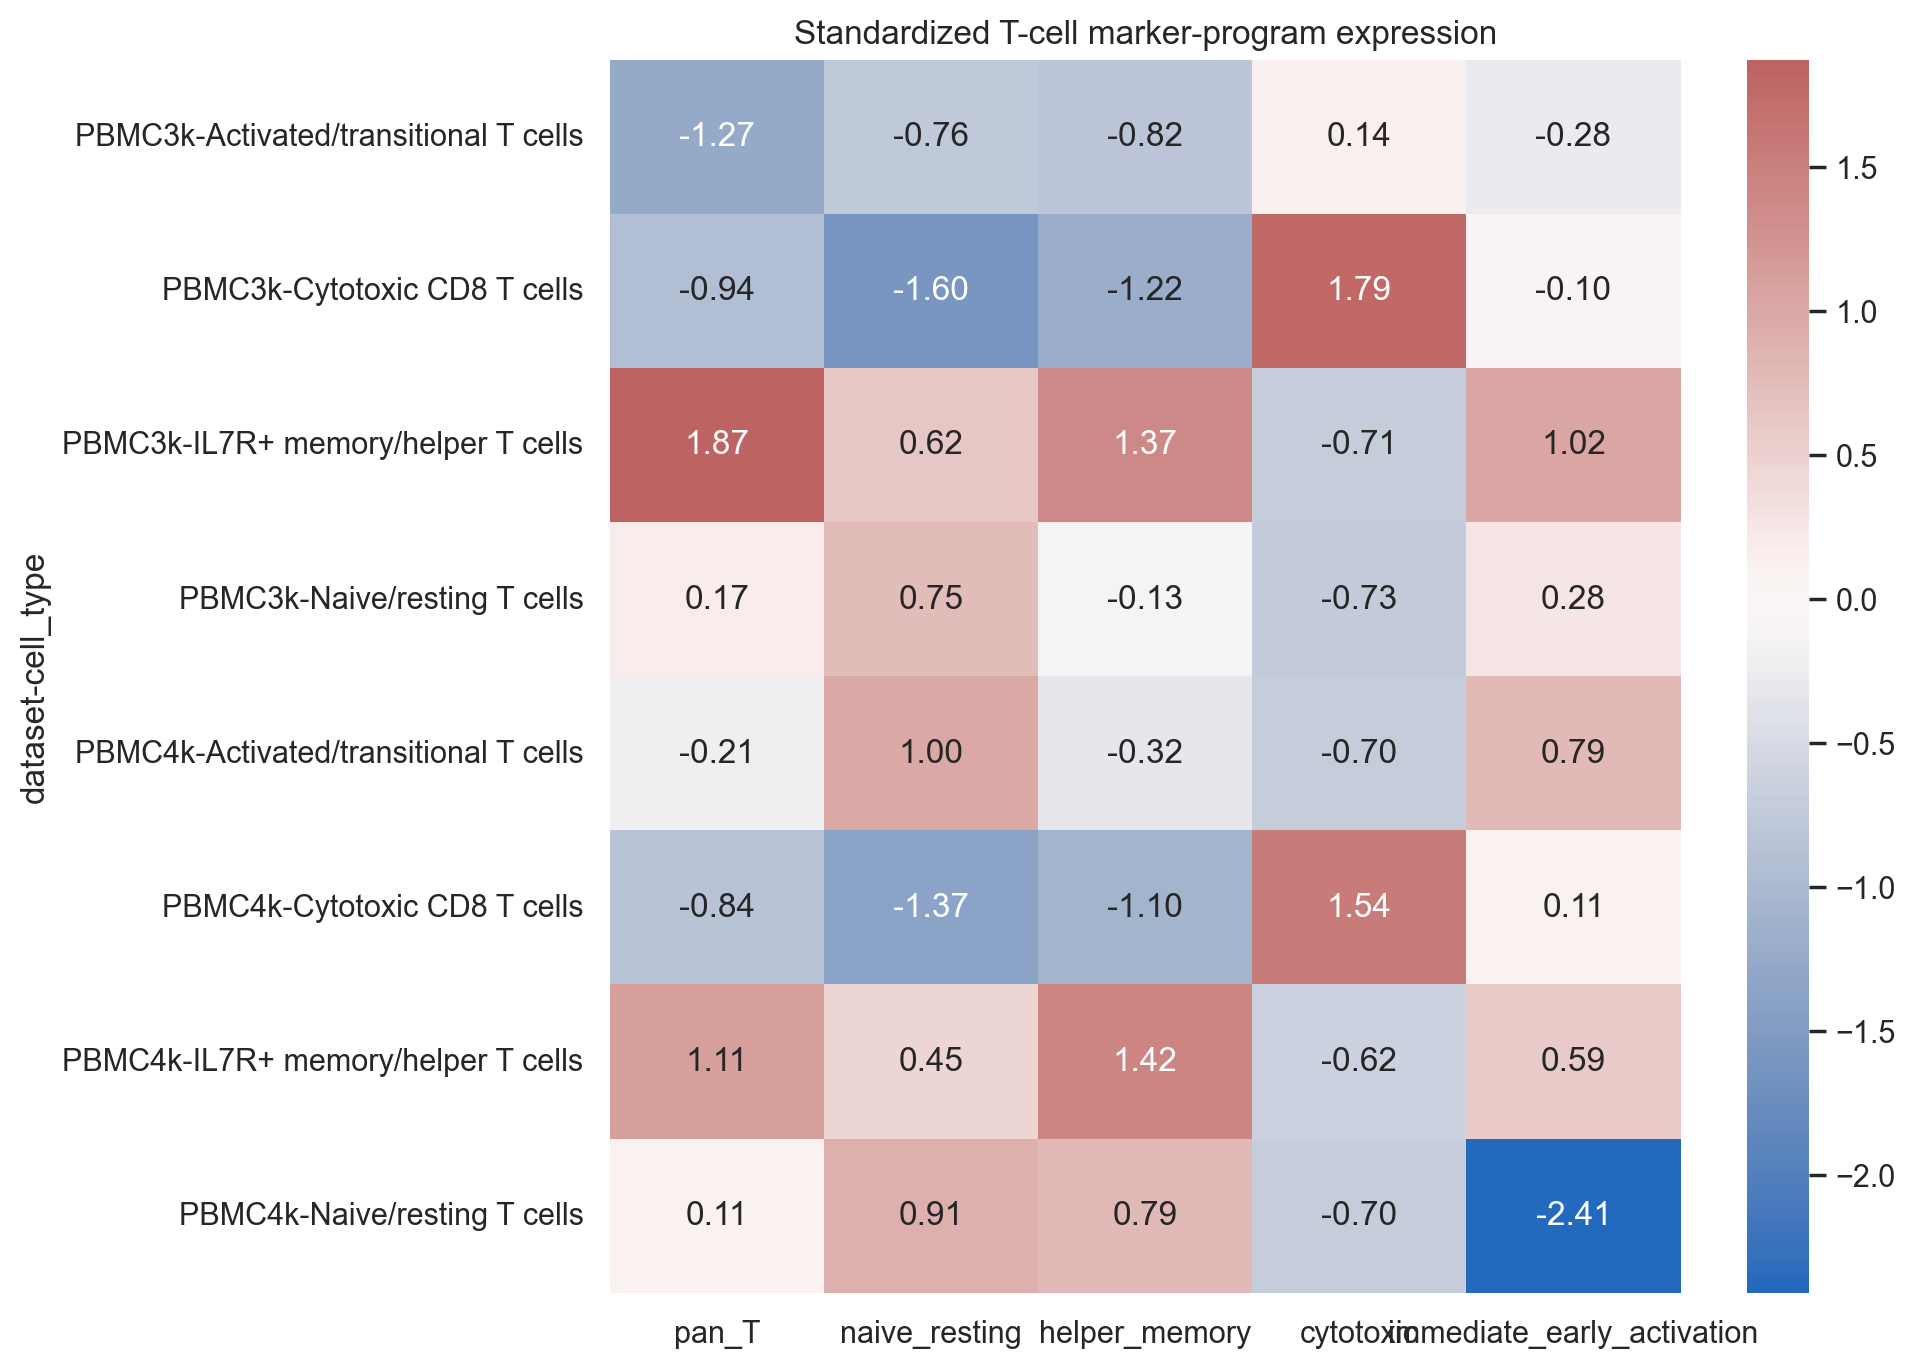

In [2]:
integrated = sc.read_h5ad(INPUT)
t_mask = integrated.obs["cell_type"].astype(str).isin(T_CELL_TYPES).to_numpy()
t_obs = integrated.obs.loc[t_mask, ["dataset", "donor", "cell_type"]].copy()
t_raw = integrated[t_mask].raw

program_genes_used = {}
for program, genes in MARKER_PROGRAMS.items():
    present = [gene for gene in genes if gene in t_raw.var_names]
    program_genes_used[program] = present
    values = t_raw[:, present].X
    t_obs[program] = np.asarray(values.mean(axis=1)).ravel()

program_columns = list(MARKER_PROGRAMS)
program_summary = t_obs.groupby(["dataset", "cell_type"], observed=True)[program_columns].mean()
program_summary.to_csv(TABLES / "pbmc_tcell_marker_program_scores.csv")
display(program_summary.round(3))

plot_table = program_summary.copy()
plot_z = pd.DataFrame(
    StandardScaler().fit_transform(plot_table), index=plot_table.index, columns=plot_table.columns
)
plt.figure(figsize=(10, 7))
sns.heatmap(plot_z, annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("Standardized T-cell marker-program expression")
plt.tight_layout()
plt.savefig(FIGURES / "pbmc_tcell_marker_program_heatmap.png", dpi=180, bbox_inches="tight")
plt.show()

## 3. Quantify cross-dataset label correspondence

Cosine similarity compares each PBMC3k label with each PBMC4k label after standardizing the five program scores. Values near 1 indicate similar relative programs.

PBMC4k reviewed label,Activated/transitional T cells,Cytotoxic CD8 T cells,IL7R+ memory/helper T cells,Naive/resting T cells
PBMC3k reviewed label,,,,
Activated/transitional T cells,-0.214,0.748,-0.900,-0.187
Cytotoxic CD8 T cells,-0.545,0.997,-0.800,-0.444
IL7R+ memory/helper T cells,0.270,-0.732,0.966,-0.014
Naive/resting T cells,0.896,-0.775,0.428,0.143


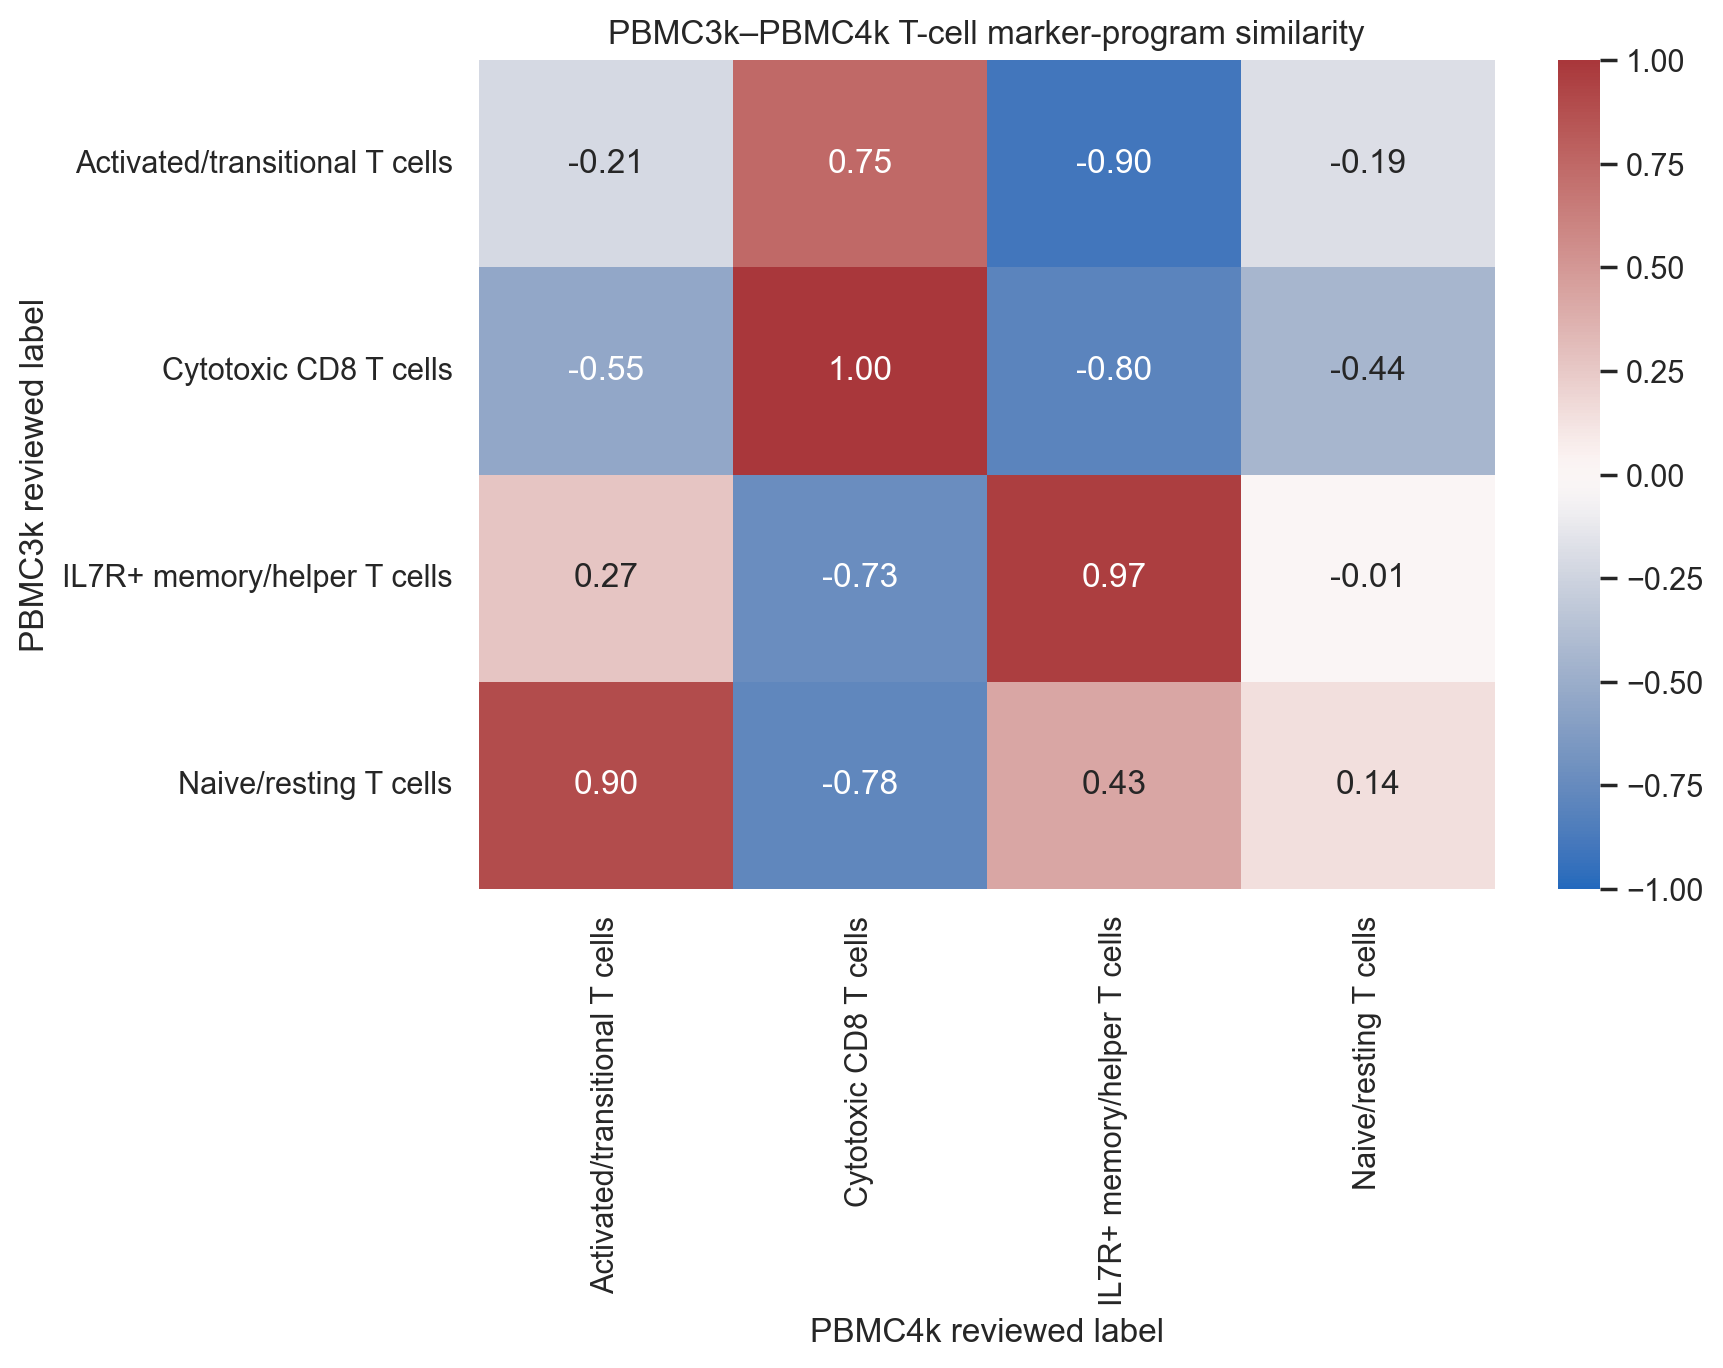

In [3]:
standardized_profiles = pd.DataFrame(
    StandardScaler().fit_transform(program_summary),
    index=program_summary.index,
    columns=program_summary.columns,
)
profile_similarity = pd.DataFrame(
    cosine_similarity(standardized_profiles.loc["PBMC3k"], standardized_profiles.loc["PBMC4k"]),
    index=standardized_profiles.loc["PBMC3k"].index,
    columns=standardized_profiles.loc["PBMC4k"].index,
)
profile_similarity.index.name = "PBMC3k reviewed label"
profile_similarity.columns.name = "PBMC4k reviewed label"
profile_similarity.to_csv(TABLES / "pbmc_tcell_cross_dataset_program_similarity.csv")
display(profile_similarity.round(3))

plt.figure(figsize=(9, 7))
sns.heatmap(profile_similarity, annot=True, fmt=".2f", cmap="vlag", vmin=-1, vmax=1, center=0)
plt.title("PBMC3k–PBMC4k T-cell marker-program similarity")
plt.tight_layout()
plt.savefig(FIGURES / "pbmc_tcell_cross_dataset_program_similarity.png", dpi=180, bbox_inches="tight")
plt.show()

## 4. T-cell-only Harmony representation and clustering sensitivity

Global dimension reduction is optimized for differences among all PBMC lineages. This sensitivity analysis recomputes variable genes, PCA, Harmony, neighbors, UMAP, and Leiden using only T cells. Ribosomal and mitochondrial genes are excluded from PCA features, but normalized expression remains intact.

In [4]:
tcells = integrated[t_mask].raw.to_adata()
tcells.raw = tcells.copy()
sc.pp.highly_variable_genes(tcells, flavor="seurat", n_top_genes=2000, batch_key="dataset")
feature_mask = (
    tcells.var["highly_variable"].to_numpy()
    & ~tcells.var_names.str.startswith(("RPL", "RPS", "MT-"))
)
tcells = tcells[:, feature_mask].copy()
tcells.layers["log_normalized"] = tcells.X.copy()
sc.pp.scale(tcells, max_value=10)
sc.tl.pca(tcells, n_comps=30, svd_solver="arpack", random_state=RANDOM_STATE)
tcells.obsm["X_pca_uncorrected"] = tcells.obsm["X_pca"].copy()
sce.pp.harmony_integrate(
    tcells,
    key="dataset",
    basis="X_pca_uncorrected",
    adjusted_basis="X_pca_harmony",
    random_state=RANDOM_STATE,
    max_iter_harmony=20,
)
sc.pp.neighbors(tcells, n_neighbors=15, use_rep="X_pca_harmony", key_added="harmony", random_state=RANDOM_STATE)
sc.tl.umap(tcells, neighbors_key="harmony", random_state=RANDOM_STATE)

resolution_rows = []
for resolution in [0.2, 0.3, 0.4, 0.5, 0.6, 0.8]:
    key = f"leiden_tcell_{str(resolution).replace('.', '_')}"
    sc.tl.leiden(tcells, resolution=resolution, neighbors_key="harmony", key_added=key, random_state=RANDOM_STATE)
    resolution_rows.append({
        "resolution": resolution,
        "clusters": tcells.obs[key].nunique(),
        "cluster_dataset_nmi": normalized_mutual_info_score(tcells.obs["dataset"].astype(str), tcells.obs[key].astype(str)),
        "cluster_original_label_nmi": normalized_mutual_info_score(tcells.obs["cell_type"].astype(str), tcells.obs[key].astype(str)),
        "smallest_cluster": tcells.obs[key].value_counts().min(),
    })
resolution_diagnostics = pd.DataFrame(resolution_rows)
resolution_diagnostics.to_csv(TABLES / "pbmc_tcell_harmony_resolution_diagnostics.csv", index=False)
display(resolution_diagnostics.round(4))

SELECTED_CLUSTER_KEY = "leiden_tcell_0_4"
cluster_by_dataset = pd.crosstab(tcells.obs[SELECTED_CLUSTER_KEY], tcells.obs["dataset"])
cluster_by_label = pd.crosstab(tcells.obs[SELECTED_CLUSTER_KEY], tcells.obs["cell_type"])
cluster_by_dataset.to_csv(TABLES / "pbmc_tcell_harmony_cluster_dataset_counts.csv")
cluster_by_label.to_csv(TABLES / "pbmc_tcell_harmony_cluster_original_label_counts.csv")
display(cluster_by_dataset)
display(cluster_by_label)

extracting highly variable genes


    finished (0:00:00)


computing PCA


    with n_comps=30


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


...

running Leiden clustering


    finished (0:00:03)


,resolution,clusters,cluster_dataset_nmi,cluster_original_label_nmi,smallest_cluster
0,0.2,3,0.0123,0.5058,780
1,0.3,3,0.0135,0.5230,790
2,0.4,3,0.0141,0.5288,821
3,0.5,4,0.0130,0.4547,622
4,0.6,4,0.0132,0.4614,626
5,0.8,6,0.0120,0.4641,54


dataset,PBMC3k,PBMC4k
leiden_tcell_0_4,,
0,615,1228
1,549,535
2,289,532


cell_type,Activated/transitional T cells,Cytotoxic CD8 T cells,IL7R+ memory/helper T cells,Naive/resting T cells
leiden_tcell_0_4,,,,
0,1075,34,134,600
1,91,66,888,39
2,37,761,20,3


## 5. Broad harmonized label proposal

In [5]:
mapping_rows = [
    ["PBMC3k", "Activated/transitional T cells", "Cytotoxic T cells", "CCL5/GZMK cytotoxic-transitional markers; PBMC4k-model predictions split mainly between activated and cytotoxic"],
    ["PBMC3k", "Cytotoxic CD8 T cells", "Cytotoxic T cells", "Strong CCL5/NKG7/CST7/CTSW cytotoxic program"],
    ["PBMC3k", "IL7R+ memory/helper T cells", "Non-cytotoxic T cells", "Strong IL7R/LTB helper-memory program"],
    ["PBMC3k", "Naive/resting T cells", "Non-cytotoxic T cells", "Naive/resting program; aligns with the large PBMC4k activation-state neighborhood"],
    ["PBMC4k", "Activated/transitional T cells", "Non-cytotoxic T cells", "Immediate-early activation is a cell state; marker profile and Harmony neighborhood align mainly with non-cytotoxic PBMC3k T cells"],
    ["PBMC4k", "Cytotoxic CD8 T cells", "Cytotoxic T cells", "Strong CCL5/NKG7/CST7/CTSW cytotoxic program"],
    ["PBMC4k", "IL7R+ memory/helper T cells", "Non-cytotoxic T cells", "Strong IL7R/LTB helper-memory program"],
    ["PBMC4k", "Naive/resting T cells", "Non-cytotoxic T cells", "Strong naive/resting program with low immediate-early activation"],
]
mapping = pd.DataFrame(mapping_rows, columns=["dataset", "original_cell_type", "proposed_harmonized_cell_type", "evidence"])
mapping.to_csv(TABLES / "pbmc_tcell_harmonized_label_proposal.csv", index=False)
display(mapping)

mapping_lookup = mapping.set_index(["dataset", "original_cell_type"])["proposed_harmonized_cell_type"].to_dict()
def harmonize_label(dataset, label):
    if label in RARE_EXCLUDED:
        return pd.NA
    return mapping_lookup.get((dataset, label), label)

cell_labels = integrated.obs[["dataset", "donor", "cell_type"]].copy()
cell_labels = cell_labels.rename(columns={"cell_type": "original_cell_type"})
cell_labels["harmonized_cell_type"] = [
    harmonize_label(dataset, label)
    for dataset, label in zip(cell_labels["dataset"].astype(str), cell_labels["original_cell_type"].astype(str))
]
cell_labels["included_in_shared6_model"] = cell_labels["harmonized_cell_type"].notna()
cell_labels.to_csv(TABLES / "pbmc_harmonized6_cell_labels.csv", index_label="cell_id")
display(pd.crosstab(cell_labels["harmonized_cell_type"], cell_labels["dataset"]))

included = cell_labels["included_in_shared6_model"].to_numpy()
harmonized = integrated[included].copy()
harmonized.obs["original_cell_type"] = cell_labels.loc[included, "original_cell_type"].astype(str).to_numpy()
harmonized.obs["harmonized_cell_type"] = pd.Categorical(cell_labels.loc[included, "harmonized_cell_type"].astype(str))
harmonized.uns["harmonized_label_policy"] = {
    "classes": sorted(harmonized.obs["harmonized_cell_type"].unique().tolist()),
    "excluded": RARE_EXCLUDED,
    "fine_tcell_labels_retained_in": "obs['original_cell_type']",
    "specialist_model_trained": False,
}
HARMONIZED_OUT = DATA_OUT / "pbmc3k_pbmc4k_harmonized6_no_rare.h5ad"
harmonized.write_h5ad(HARMONIZED_OUT, compression="gzip")
print(f"Saved non-destructive harmonized-label object: {HARMONIZED_OUT}")

,dataset,original_cell_type,proposed_harmonized_cell_type,evidence
0,PBMC3k,Activated/transitional T cells,Cytotoxic T cells,CCL5/GZMK cytotoxic-transitional markers; PBMC...
1,PBMC3k,Cytotoxic CD8 T cells,Cytotoxic T cells,Strong CCL5/NKG7/CST7/CTSW cytotoxic program
2,PBMC3k,IL7R+ memory/helper T cells,Non-cytotoxic T cells,Strong IL7R/LTB helper-memory program
3,PBMC3k,Naive/resting T cells,Non-cytotoxic T cells,Naive/resting program; aligns with the large P...
4,PBMC4k,Activated/transitional T cells,Non-cytotoxic T cells,Immediate-early activation is a cell state; ma...
5,PBMC4k,Cytotoxic CD8 T cells,Cytotoxic T cells,Strong CCL5/NKG7/CST7/CTSW cytotoxic program
6,PBMC4k,IL7R+ memory/helper T cells,Non-cytotoxic T cells,Strong IL7R/LTB helper-memory program
7,PBMC4k,Naive/resting T cells,Non-cytotoxic T cells,Strong naive/resting program with low immediat...


dataset,PBMC3k,PBMC4k
harmonized_cell_type,,
B cells,348,592
CD16+ non-classical monocytes,171,106
Classical monocytes,502,923
Cytotoxic T cells,401,588
NK cells,153,181
Non-cytotoxic T cells,1052,1707


Saved non-destructive harmonized-label object: /Users/Ema/Desktop/cosmos/26-the-backpropagators-analysis/PBMC_integrated/data/processed/pbmc3k_pbmc4k_harmonized6_no_rare.h5ad


## 6. Re-score existing predictions under the broad taxonomy

This does not retrain a model. It maps the already-saved fine-label predictions and reviewed labels into the proposed six-class taxonomy to test whether incompatible label granularity explains the transfer failures.

/Users/Ema/Desktop/cosmos/26-the-backpropagators-analysis/PBMC3k/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


,experiment,fine_label_accuracy,harmonized6_accuracy,fine_label_macro_f1,harmonized6_macro_f1,harmonized6_balanced_accuracy,cells
0,PBMC3k → PBMC4k,0.6898,0.9592,0.7137,0.9384,0.9197,4097
1,PBMC4k → PBMC3k,0.6924,0.9273,0.6906,0.9177,0.9111,2627


,experiment,cell_type,precision,recall,f1,support
0,PBMC3k → PBMC4k,B cells,0.990,0.998,0.994,592
1,PBMC3k → PBMC4k,CD16+ non-classical monocytes,0.980,0.934,0.957,106
2,PBMC3k → PBMC4k,Classical monocytes,0.995,0.990,0.992,923
3,PBMC3k → PBMC4k,Cytotoxic T cells,0.904,0.833,0.867,588
4,PBMC3k → PBMC4k,NK cells,0.952,0.768,0.850,181
5,PBMC3k → PBMC4k,Non-cytotoxic T cells,0.947,0.994,0.970,1707
6,PBMC4k → PBMC3k,B cells,0.997,0.977,0.987,348
7,PBMC4k → PBMC3k,CD16+ non-classical monocytes,0.947,0.942,0.944,171
8,PBMC4k → PBMC3k,Classical monocytes,0.980,0.980,0.980,502
9,PBMC4k → PBMC3k,Cytotoxic T cells,0.827,0.751,0.787,401


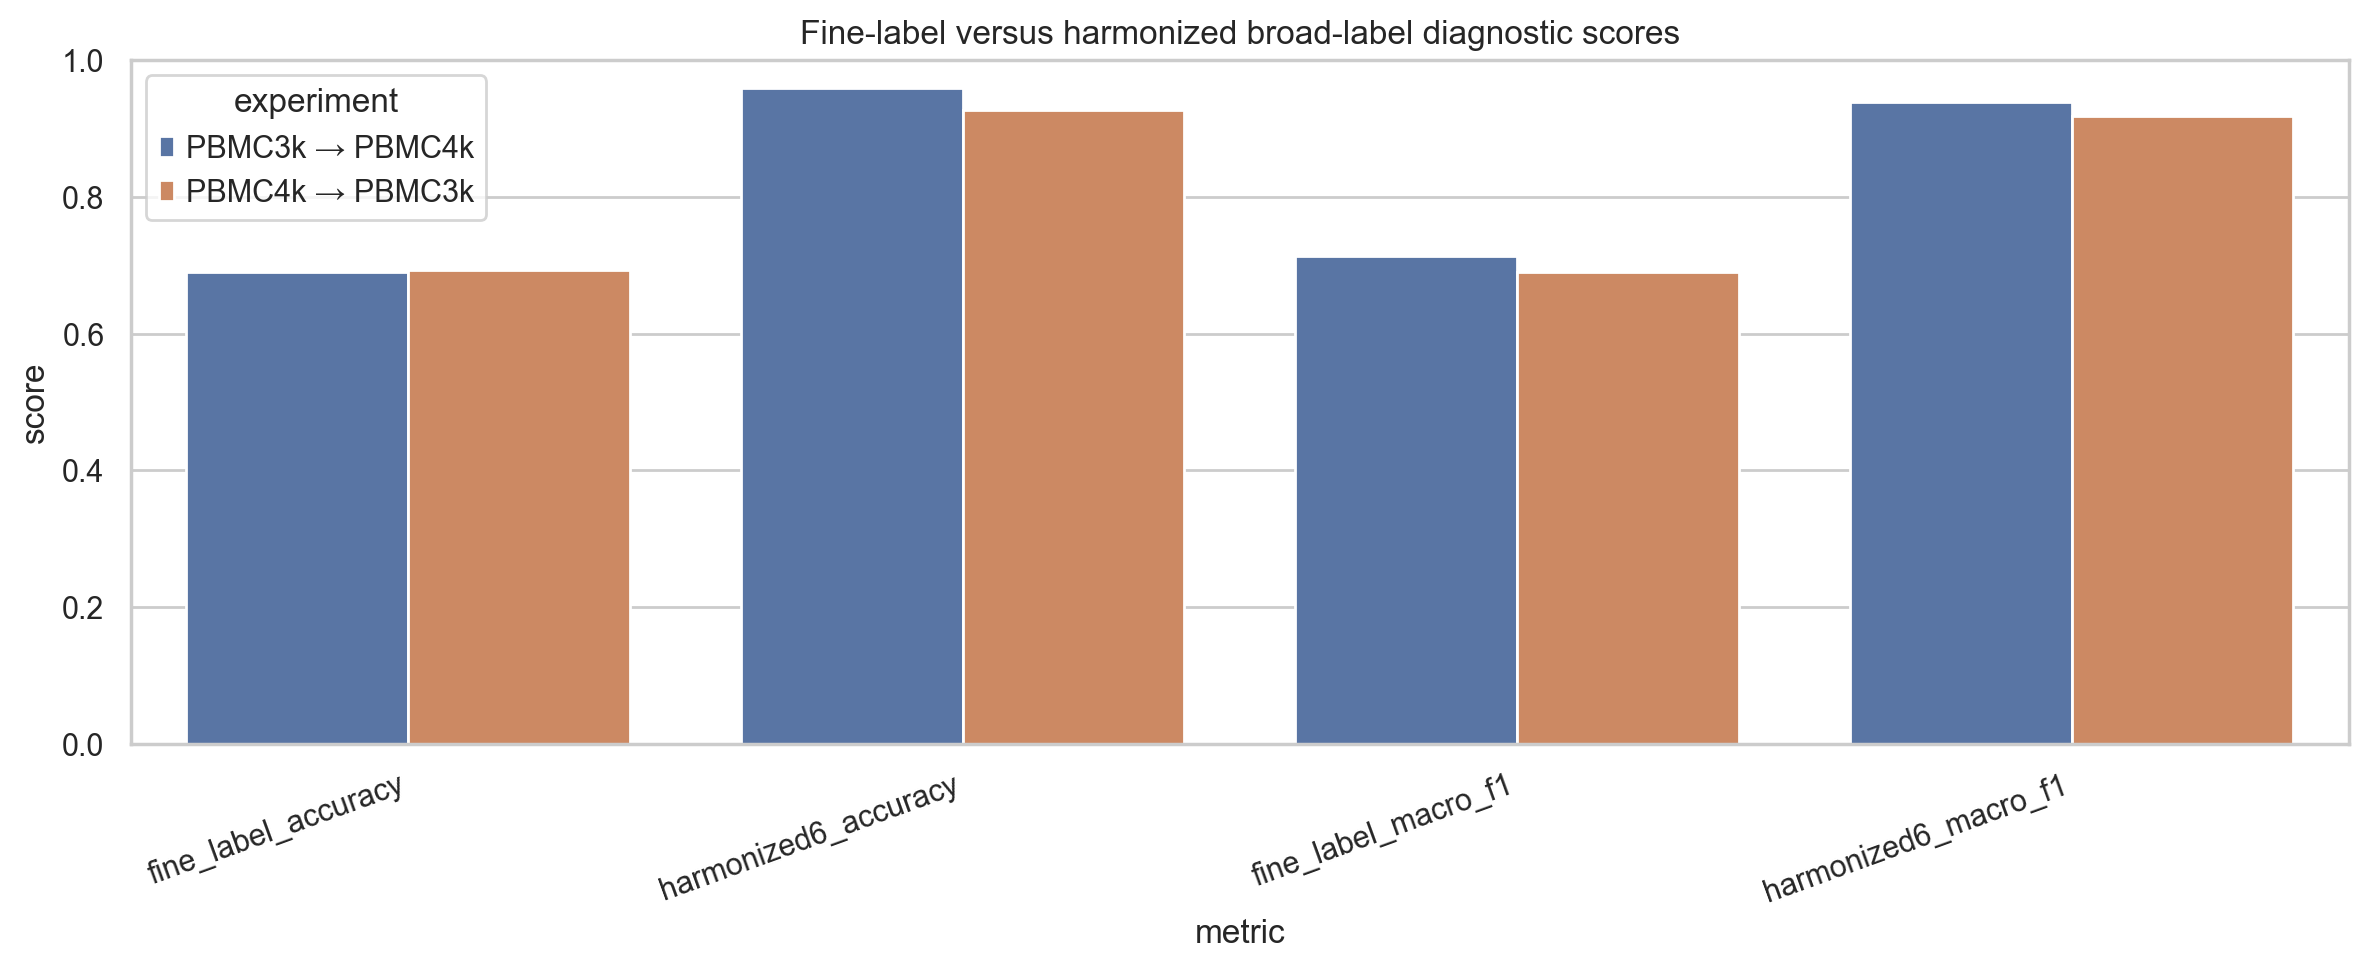

In [6]:
forward = pd.read_csv(TABLES / "pbmc_shared8_pbmc4k_cell_predictions.csv")
reverse = pd.read_csv(TABLES / "pbmc_reverse_xgboost_cell_predictions.csv")
reverse = reverse.loc[reverse["model_knows_reviewed_class"]].copy()

def map_series(values, dataset):
    return values.map(lambda label: harmonize_label(dataset, label))

experiments = {
    "PBMC3k → PBMC4k": (
        map_series(forward["reviewed_cell_type"], "PBMC4k"),
        map_series(forward["shared8_prediction"], "PBMC3k"),
    ),
    "PBMC4k → PBMC3k": (
        map_series(reverse["reviewed_cell_type"], "PBMC3k"),
        map_series(reverse["predicted_cell_type"], "PBMC4k"),
    ),
}
original_scores = {
    "PBMC3k → PBMC4k": {"accuracy": 0.689773, "macro_f1": 0.713685},
    "PBMC4k → PBMC3k": {"accuracy": 0.692425, "macro_f1": 0.690563},
}
score_rows = []
per_class_rows = []
for experiment, (truth, prediction) in experiments.items():
    valid = truth.notna()
    truth = truth.loc[valid].astype(str)
    prediction = prediction.loc[valid].astype(str)
    labels = sorted(truth.unique())
    precision, recall, f1, support = precision_recall_fscore_support(
        truth, prediction, labels=labels, zero_division=0
    )
    score_rows.append({
        "experiment": experiment,
        "fine_label_accuracy": original_scores[experiment]["accuracy"],
        "harmonized6_accuracy": accuracy_score(truth, prediction),
        "fine_label_macro_f1": original_scores[experiment]["macro_f1"],
        "harmonized6_macro_f1": f1_score(truth, prediction, labels=labels, average="macro", zero_division=0),
        "harmonized6_balanced_accuracy": balanced_accuracy_score(truth, prediction),
        "cells": len(truth),
    })
    for label, p, r, score, n in zip(labels, precision, recall, f1, support):
        per_class_rows.append({"experiment": experiment, "cell_type": label, "precision": p, "recall": r, "f1": score, "support": n})

diagnostic_scores = pd.DataFrame(score_rows)
diagnostic_per_class = pd.DataFrame(per_class_rows)
diagnostic_scores.to_csv(TABLES / "pbmc_harmonized6_transfer_diagnostic_scores.csv", index=False)
diagnostic_per_class.to_csv(TABLES / "pbmc_harmonized6_transfer_per_class.csv", index=False)
display(diagnostic_scores.round(4))
display(diagnostic_per_class.round(3))

score_plot = diagnostic_scores.melt(
    id_vars="experiment",
    value_vars=["fine_label_accuracy", "harmonized6_accuracy", "fine_label_macro_f1", "harmonized6_macro_f1"],
    var_name="metric",
    value_name="score",
)
plt.figure(figsize=(12, 5))
sns.barplot(data=score_plot, x="metric", y="score", hue="experiment")
plt.ylim(0, 1)
plt.xticks(rotation=20, ha="right")
plt.title("Fine-label versus harmonized broad-label diagnostic scores")
plt.tight_layout()
plt.savefig(FIGURES / "pbmc_harmonized6_transfer_diagnostic_scores.png", dpi=180, bbox_inches="tight")
plt.show()

## 7. Visualize the T-cell-only structure and save the review object

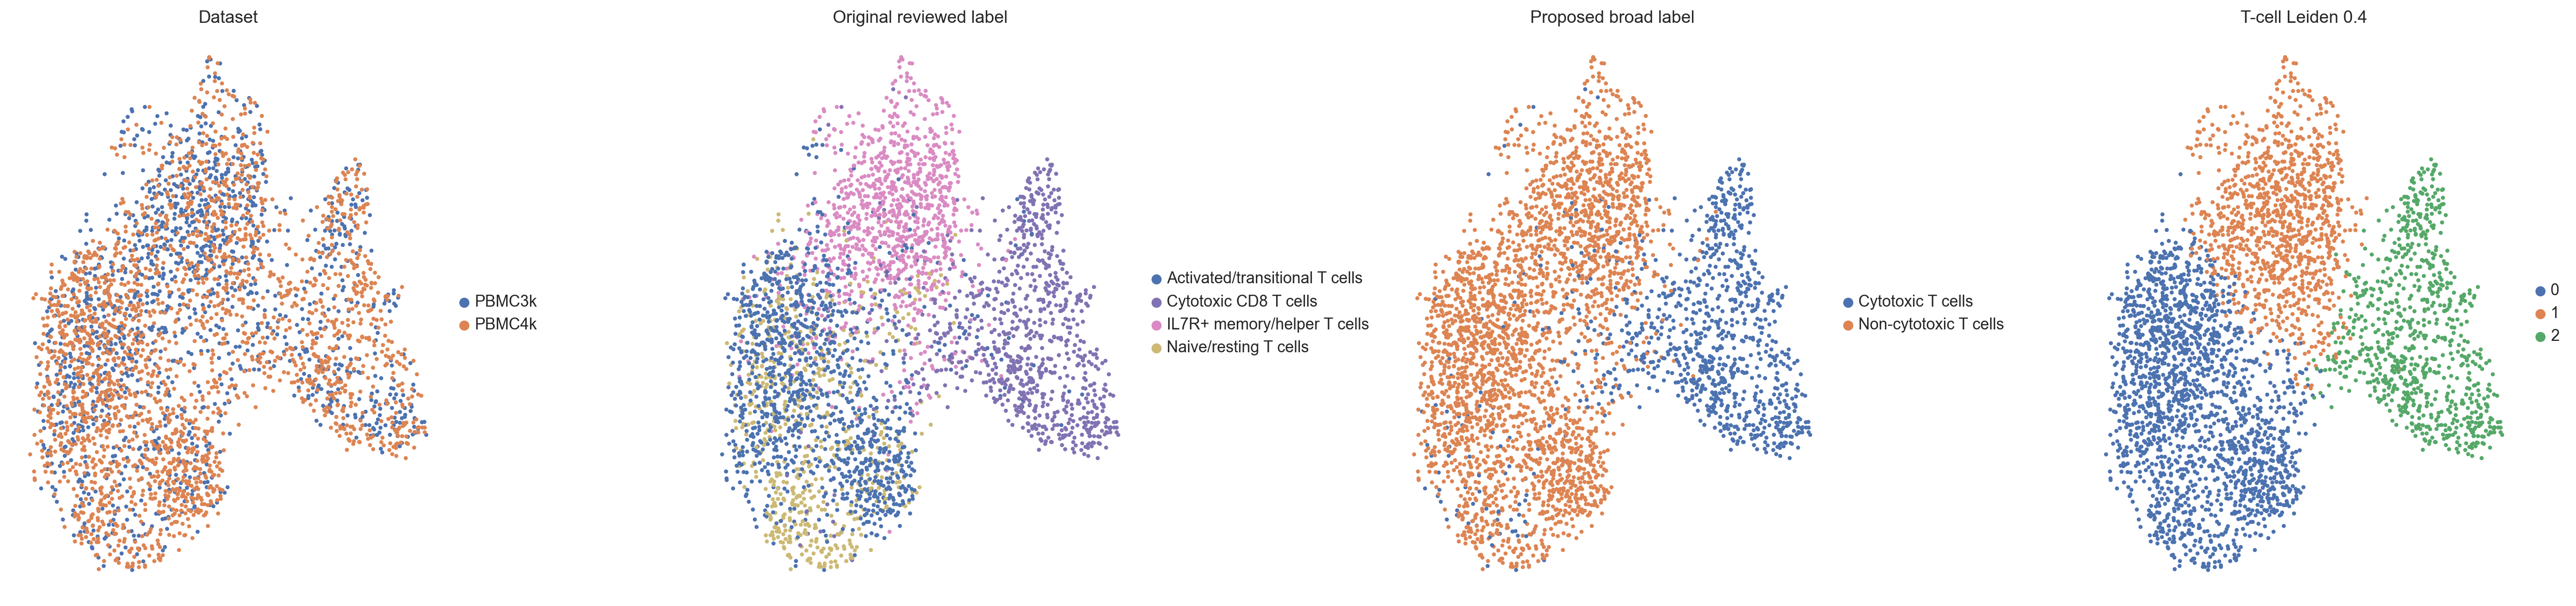

Saved T-cell review object: /Users/Ema/Desktop/cosmos/26-the-backpropagators-analysis/PBMC_integrated/data/processed/pbmc_tcell_harmony_label_review.h5ad


In [7]:
tcells.obs["harmonized_cell_type"] = pd.Categorical([
    harmonize_label(dataset, label)
    for dataset, label in zip(tcells.obs["dataset"].astype(str), tcells.obs["cell_type"].astype(str))
])
fig, axes = plt.subplots(1, 4, figsize=(25, 6))
for ax, color, title in zip(
    axes,
    ["dataset", "cell_type", "harmonized_cell_type", SELECTED_CLUSTER_KEY],
    ["Dataset", "Original reviewed label", "Proposed broad label", "T-cell Leiden 0.4"],
):
    sc.pl.umap(tcells, color=color, ax=ax, show=False, title=title, frameon=False)
fig.tight_layout()
fig.savefig(FIGURES / "pbmc_tcell_harmony_label_review_umaps.png", dpi=180, bbox_inches="tight")
plt.show()

tcells.uns["label_review"] = {
    "selected_resolution": 0.4,
    "proposal": "Two broad T-cell lineage classes; retain activation as state metadata",
    "specialist_model_trained": False,
}
TCELL_OUT = DATA_OUT / "pbmc_tcell_harmony_label_review.h5ad"
tcells.write_h5ad(TCELL_OUT, compression="gzip")
print(f"Saved T-cell review object: {TCELL_OUT}")

## Interpretation and required decision

The evidence supports a broad shared taxonomy for general cross-dataset classification:

- `Cytotoxic T cells`
- `Non-cytotoxic T cells`

Fine labels such as naive, IL7R-helper, and immediate-early activated should remain metadata/state annotations rather than mutually exclusive cross-dataset classifier targets until they are reviewed with additional donors or references. Dendritic cells and platelets remain excluded from the proposed shared model.

**No T-cell specialist has been trained. User approval is required before that step.**